### Calculating the board

In [1]:
from ultralytics import YOLO
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import glob
from utils import *

In [2]:
model_board = YOLO("../code/runs/segment/train6/weights/best.pt")

In [3]:
test_image_path = "../code/captured_images/image_70.jpg"

In [4]:
result = model_board.predict(test_image_path,retina_masks=True)


image 1/1 f:\Chess\code\..\code\captured_images\image_70.jpg: 480x640 1 Board, 1 White_start, 40.4ms
Speed: 0.8ms preprocess, 40.4ms inference, 11.4ms postprocess per image at shape (1, 3, 480, 640)


In [5]:
model_pieces = YOLO("../code/runs/detect/train9/weights/best.pt")

In [6]:
result_pieces = model_pieces.predict(test_image_path,retina_masks=True)


image 1/1 f:\Chess\code\..\code\captured_images\image_70.jpg: 480x640 1 BB, 1 BK, 6 BPs, 1 BQ, 2 BRs, 1 WB, 1 WK, 1 WKN, 3 WPs, 1 WQ, 3 WRs, 6.7ms
Speed: 0.6ms preprocess, 6.7ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)


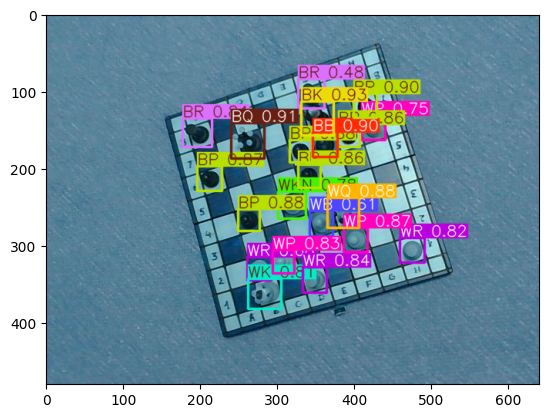

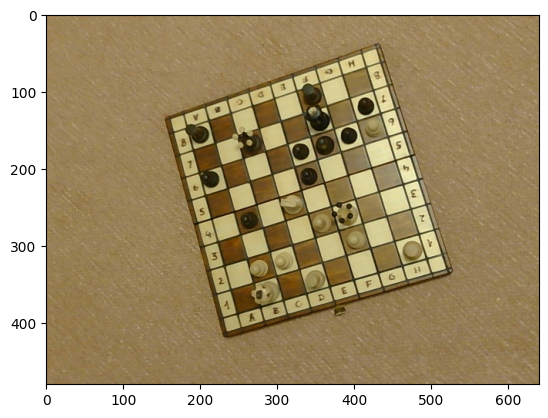

In [7]:
plt.imshow(result_pieces[0].plot())
plt.show()

image = cv2.imread(test_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()


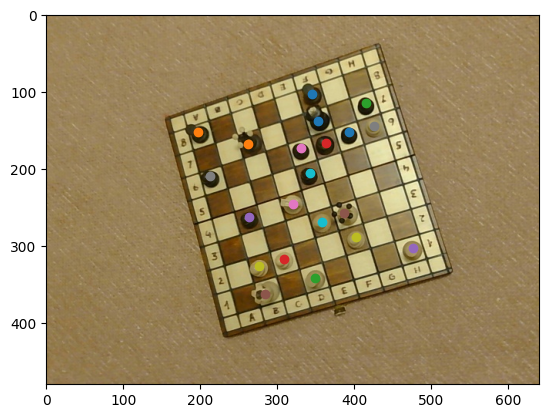

In [8]:
image = cv2.imread(test_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

for box in result_pieces[0].boxes.xywh:
    x,y,_,h = box.cpu()

    plt.scatter(x,y+h/2-20)

plt.show()

In [9]:
transformed_positions = list()
lower_y_coord = 10 #How many pixels lower from midpoint of the bounding box
H = calculate_homography(result,test_image_path)
image = cv2.imread(test_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.warpPerspective(image,H,(480,480))



for box in result_pieces[0].boxes.xywh:
    x,y,_,h = box.cpu()
    piece_pos = cv2.perspectiveTransform(np.array([[[x,y+h/2-lower_y_coord]]]), H).squeeze()
    transformed_positions.append(piece_pos)

transformed_positions = np.array(transformed_positions)


w,h = image.shape[0:2]

x = (np.linspace(0,w,9)+(w/16))[:-1]
y = (np.linspace(0,h,9)+(h/16))[:-1]


X,Y = np.meshgrid(x,y) #Define the middle points of the square

square_middles = np.stack([X.flatten(),Y.flatten()],axis=1)



diff = transformed_positions[:, None, :] - square_middles[None, :, :]




distances = np.linalg.norm(diff,axis=2)
idx = np.argmin(distances, axis=1)

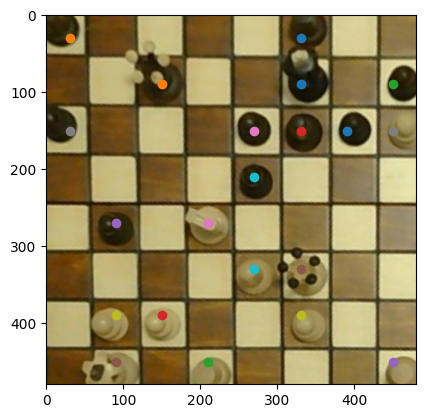

In [10]:
plt.imshow(image)

for box in square_middles[idx]:

    plt.scatter(box[0],box[1])

In [11]:
fen = create_fen(result_pieces,idx)
fen

'r4r2/2q2k1p/p3pbpP/4p3/1p1N4/4BQ2/1RP2P2/1K1R3R w - - 0 1'

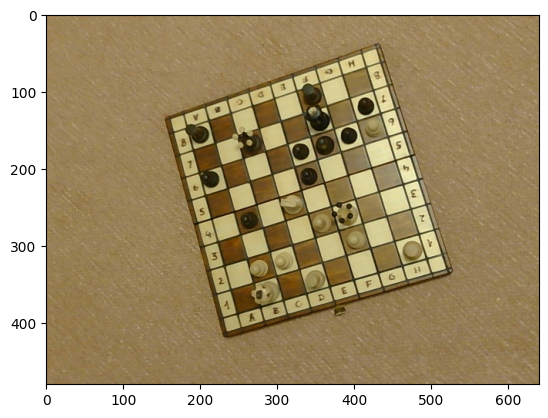

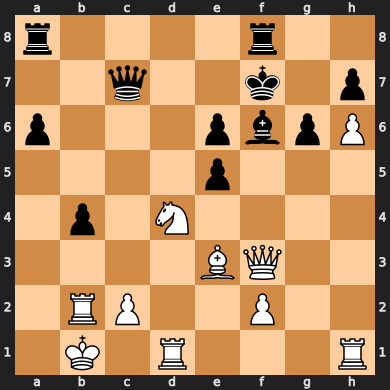

In [12]:
import chess
board = chess.Board(fen)
image = cv2.imread(test_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()
board

[[        490         325]
 [        491         337]
 [        254         389]
 [        252         402]]


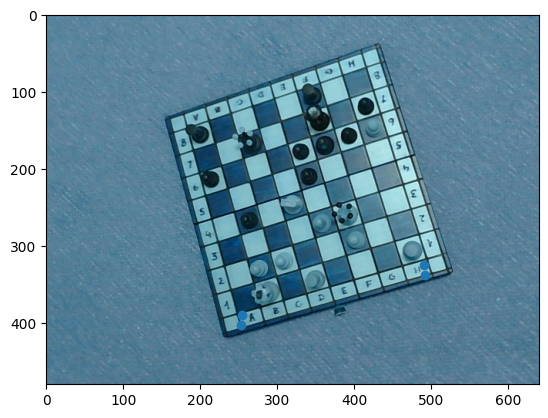

In [24]:



image = cv2.imread(test_image_path)
zeros_img = np.zeros_like(image[:,:,0],dtype=np.uint8)


detection_dict = result[0].names
board_label = [k for k, v in detection_dict.items() if v == "Board"][0]
white_label = [k for k, v in detection_dict.items() if v == "White_start"][0]
objects_detected = result[0].boxes.cls
idx_board = (objects_detected == board_label).nonzero(as_tuple=True)[0][0].item()
idx_white = (objects_detected == white_label).nonzero(as_tuple=True)[0][0].item()

#This section finds the corners of the board, based on the board mask.
board_mask = result[0].masks.xy[idx_board].astype(np.int32) #extract mask

image = cv2.imread(test_image_path)
zeros_img = np.zeros_like(image[:,:,0],dtype=np.uint8)


mask_boundary = cv2.polylines(zeros_img,     #Create a boundary of the mask
    [board_mask],
    isClosed=True,
    color=255,
    thickness=1
)

corners_1 = harris_corners(mask_boundary)




detection_dict = result[0].names
white_label = [k for k, v in detection_dict.items() if v == "White_start"][0]
objects_detected = result[0].boxes.cls
idx_white = (objects_detected == white_label).nonzero(as_tuple=True)[0][0].item()
board_mask = result[0].masks.xy[idx_white].astype(np.int32) #extract mask
mask_boundary = cv2.polylines(zeros_img,     #Create a boundary of the mask
    [board_mask],
    isClosed=True,
    color=255,
    thickness=1
)

corners_2 = harris_corners(mask_boundary,minDistance=12)
plt.imshow(image)
print(corners)
plt.scatter(corners[:,0],corners[:,1])
plt.show()

In [32]:
import numpy as np
from sklearn.cluster import DBSCAN

def unique_points(points, eps=5.0):
    """
    points: Nx2 array of (x, y) coordinates
    eps: max distance between points to consider them duplicates
    """
    points = np.array(points)

    # Cluster points based on proximity
    clustering = DBSCAN(eps=eps, min_samples=1).fit(points)
    labels = clustering.labels_

    unique = []
    for label in np.unique(labels):
        cluster_points = points[labels == label]
        # Use the centroid of each cluster as the representative point
        unique.append(cluster_points.mean(axis=0))

    return np.array(unique)

# Example usage:
points = np.vstack([corners_1,corners_2])

unique_pts = unique_points(points, eps=10.0)
print(unique_pts)


[[        190         151]
 [        409          75]
 [      490.5       312.5]
 [      250.5       378.5]
 [        487         325]
 [        253         392]]
